# LINMA2222 - Stochastic Optimal Control & Reinforcement Learning
## Portfolio optimal strategy
---

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)  # For reproducibility

### Constants

In [2]:
THETA = 0.5
W_A = 0.1
W_U = 0.2
SIGMA_A = 0.018
SIGMA_P = 0.02
BETA_U = -0.048
GAMMA_U = 0.06

In [3]:
RUN_CL = False
RUN_CMA = False
RUN_LQR = False
RUN_MPC = False
RUN_EPIA = True
RUN_QLAMBDA = True

### Plot functions

In [4]:
from model import *

### Question 3.1

$\pi_{cl}(x_t) = K_{cl} x_t$


In [5]:
rng = np.random.default_rng(42)  # For reproducibility

# Question 3.1.1
policy = lambda x: -0.5 * x[0] + 0.5 * x[1] + 0.5 * x[2]
cliped_policy = lambda x: np.clip(policy(x), -x[0], 1-x[0])
random_policy = lambda x: rng.uniform(-x[0] * 0.1, (1 - x[0]) * 0.1)

# x, u, xi_p = generate_trajectories(policy, x0=(0, 0, 0), T=1000)
# plot_trajectories(x, u, xi_p, filename="question_3_1_unclipped", policy_name="Unclipped Initial Policy")
# plot_average_reward(x, u, xi_p, filename="question_3_1_unclipped", policy_name="Unclipped Initial Policy")


# x, u, xi_p = generate_trajectories(cliped_policy, x0=(0, 0, 0), T=1000)
# plot_trajectories(x, u, xi_p, filename="question_3_3_clipped", policy_name="Clipped Initial Policy")
# plot_average_reward(x, u, xi_p, filename="question_3_3_clipped", policy_name="Clipped Initial Policy")



policy_list = [(policy, "Initial Policy"), (cliped_policy, "Clipped Initial Policy")]



In [6]:
### simulate trajectories and plot the average reward over time
# Question 3.1.2
if RUN_CL:
    run_trajectories(policy, N=1000, name="unclipped policy", show_all=True)
    run_trajectories(cliped_policy, N=1000, name="clipped policy", show_all=True)

### CMA

In [7]:
from best_policy import get_cma, get_cma_quadratic

best_params_cma, best_policy_cma = get_cma(recompute=False)
policy_list.append((best_policy_cma, "Best linear Policy (CMA-ES)"))
if RUN_CMA:
    run_trajectories(best_policy_cma, N=100, name="best policy (CMA-ES)", show_all=True)
# best_params_cma_quadratic, best_policy_cma_quadratic = get_cma_quadratic(recompute=True)
# policy_list.append((best_policy_cma_quadratic, "Best quadratic Policy (CMA-ES)"))
# run_trajectories(best_policy_cma_quadratic, N=1000, name="best quadratic policy (CMA-ES)", show_all=True)

In [8]:

# x, u, xi_p = generate_trajectories(best_params_cma_quadratic, x0=(0, 0, 0), T=1000)
# plot_trajectories(x, u, xi_p, filename="question_3_1_1_clipped")
# plot_average_reward(x, u, xi_p, filename="question_3_1_1_clipped")

# Question 4.4 

In [9]:
#### SYSTEM MATRICES
# Define system matrices based on the problem description
F = np.array([[1, 0, 0], 
              [0, 1 - W_A, 0], 
              [0, 0, 1 - W_U]])

G = np.array([[1], 
              [0], 
              [W_U * BETA_U]])

D = np.array([[0, 0], [W_A * SIGMA_A, 0], [0, 0]])  # Disturbance matrix
  
# maximise r(x,u) = 0.5 x.T S x + x.T P u + 0.5 u.T R u 
# minimise - r(x,u)
# given    x_t+1 = F x_t + G u_t + D xi_t
S = np.array([[-(1000 * SIGMA_P)**2, 1000, 1000], 
                     [1000, 0, 0], 
                     [1000, 0, 0]]) 

P = np.array([[1000*GAMMA_U - THETA * ((1000 * SIGMA_P)**2)], 
                     [1000 * THETA], 
                     [1000 * THETA]]) 

R = np.array([[- (1000 * THETA * SIGMA_P)**2]])

# min c(x,u) = x.T Q x + u.T R u + 2 x.T S u = - 0.5 r(x,u)
Q = -0.5 * S
S = -0.5 * P
R = -0.5 * R

nu = 1  # number of inputs  = 1
nx = 3  # number of states  = 3
ny = 3  # number of outputs = 3

H = np.eye(ny)         # Output matrix (assuming full state observation)  # ny x nx
E = np.zeros((ny, 1))  # Direct feedthrough (assuming none)  # ny x nu

# we use F, G, Q, R, S from before
# min x.T Q x + u.T R u + 2 x.T S u
R_0 = Q # last stage cost  # nx x nx

model = (F, G, H, E, D, Q, R, S)


In [10]:
np.random.seed(42)

from lqr import compute_lqr_gain

K_lqr = compute_lqr_gain(model)
# K_lqr = compute_lqr_gain((F, G, np.zeros((H.shape[0], H.shape[1])), E, np.zeros((D.shape[0], D.shape[1])), Q, R, S))


lqr_policy = lambda x: K_lqr @ x
lqr_clip_policy = lambda x: np.clip(lqr_policy(x), -x[0], 1 - x[0])

print("=" * 50)
# x, u, xi_p = generate_trajectories(lqr_policy, x0=(0, 0, 0), T=1000, N=1000)
# x, u, xi_p = generate_trajectories(lqr_clip_policy, x0=(0, 0, 0), T=1000, N=1000)


# x, u, xi_p = generate_trajectories(lqr_policy, x0=(0, 0, 0), T=1000, N=10, xi_p=np.zeros((1000, 10)))
# plot_average_reward(x, u, xi_p, filename="lqr_optimal_policy")
# plot_trajectories(x, u, xi_p, filename="lqr_optimal_policy")


# print(f"LQR Optimal Policy Average Reward: {average_reward(x, u, xi_p, 1000)}")
# # plot_trajectories(x, u, xi_p, T=1000)
# # plot_average_reward(x, u, xi_p, filename="lqr_optimal_policy")

if RUN_LQR:
    run_trajectories(lqr_policy, N=100, T=1000, name="LQR Optimal Policy", show_all=True)
    run_trajectories(lqr_clip_policy, N=100, T=1000, name="LQR Clip Policy", show_all=True)


policy_list.append((lqr_policy, "LQR Optimal Policy"))
policy_list.append((lqr_clip_policy, "LQR Clip Policy"))

K_lqr : [[-1.11182191  2.64863317  2.52792524]]  residual norm: 5.4606211020642276e-11
Stable: True
Average approximate reward J: 0.019355062306099072


In [11]:
from mpc import get_mpc_policy
from mpc_condensed import get_mpc_condensed_policy
import numpy as np
N = 10



u_min, u_max = [None], [None]  # scalar
y_min = np.array([0, None, None], dtype=object)  # (ny x 1)
y_max = np.array([1, None, None], dtype=object)   # (ny x 1)


mpc_policy = get_mpc_policy(N, model, y_min, y_max, u_min, u_max)
mpc_policy_condensed = get_mpc_condensed_policy(N, model, y_min, y_max, u_min, u_max)
# test
if RUN_MPC:
    run_trajectories(mpc_policy, N=10, T=100, name="MPC Optimal Policy", show_all=True, show_progress=True)






In [12]:
### MPC



N = 10


if RUN_MPC:
    compare_policies(mpc_policy, mpc_policy_condensed, N=100)
policy_list.append((mpc_policy_condensed, "MPC Optimal Policy"))

# takes 30 min to run
# run_trajectories(mpc_policy_condensed, N=1, T=1000, name="MPC Optimal Policy", show_all=True, show_progress=True)
# run_trajectories(mpc_policy_condensed, N=100, T=1000, name="MPC Optimal Policy", show_all=True, show_progress=True)

# interesting graph
if RUN_MPC:
    x, u, xi_p = generate_trajectories(mpc_policy_condensed, x0=(0, 0, 0), T=100, N=1, xi_p=np.zeros((1000, 10)), show_progress=True)
    plot_average_reward(x, u, xi_p, filename="mpc_optimal_policy_without_noise")



    

In [13]:

def compare_policies(po_lst, N=1, T=1000):
    # generate random xi
    xi_p = np.random.normal(0, 1, (T, N))
    xi_a = np.random.normal(0, SIGMA_A, (T, N))
    rewards, stds = [], []
    for pol in po_lst:
        policy, name = pol
        all_x, all_u, all_xi_p = generate_trajectories(policy, x0=(0, 0, 0), T=T, N=N, xi_p=xi_p, xi_a=xi_a)
        all_rewards = reward(all_x, all_u, all_xi_p, T).T
        reward_value = np.nanmean(all_rewards)
        reward_std = np.nanstd(all_rewards)
        print(f"Average reward of policy {name} over {N} trajectories: {reward_value} and std: {reward_std}")
        rewards.append(reward_value)
        stds.append(reward_std)
    
    # plot bar chart of rewards with error bars
    plt.figure(figsize=(10, 6))
    plt.bar([name for _, name in po_lst], rewards, capsize=5)
    plt.ylabel("Average Reward")
    plt.title(f"Policy Comparison over {N} Trajectories and {T} Time Steps")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig("policy_comparison.png")

if RUN_MPC:
    compare_policies([(get_mpc_condensed_policy(i, model, y_min, y_max, u_min, u_max)
                   , f"MPC Optimal Policy N={i}") for i in range(2, 31)], N=1, T=10)


In [14]:
#### graphs of N vs reward
#### too much variance
# Ns = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 25, 30]
# rewards = []
# for N in Ns:
#     pol = get_mpc_condensed_policy(N)
#     x, u, xi_p = generate_trajectories(pol, x0=(0, 0, 0), T=1000, N=1, show_progress=True)
#     rewards_N = c(g(x[0, :, :], x[1, :, :], x[2, :, :], u[0, :])).T
#     plt.plot(N * np.ones_like(rewards_N), rewards_N, 'o', alpha=0.3, label=f"N={N}" if N==Ns[0] else "")
#     rewards.append(np.mean(rewards_N))
#     print(f"N={N}, Average reward: {np.mean(rewards_N)}, std: {np.std(rewards_N)}")

# plt.figure()
# plt.plot(Ns, rewards, marker='o')
# plt.xlabel('MPC Horizon N')
# plt.ylabel('Average Reward')
# plt.title('Average Reward vs MPC Horizon')
# plt.grid()
# plt.savefig("figures/mpc_horizon_vs_reward.svg", format='svg')

# Q5 EPIA


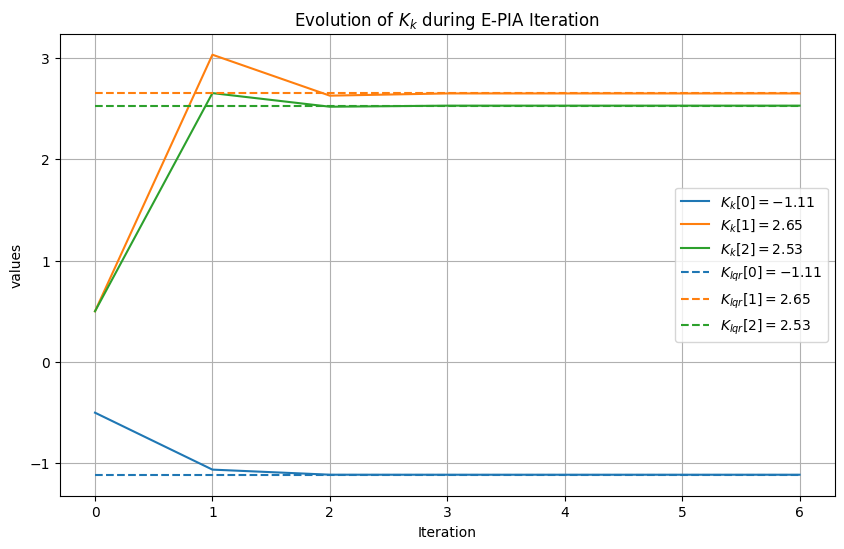

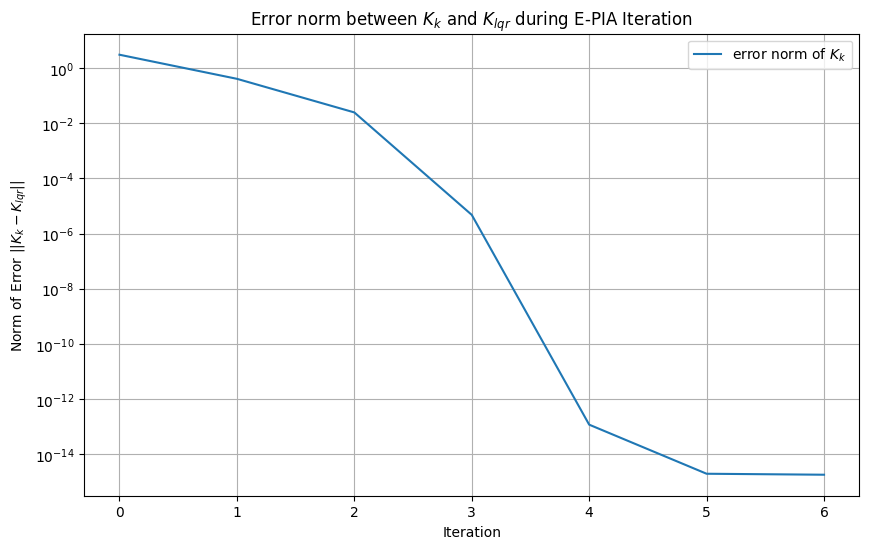

In [15]:
### plot K_list
from e_pia import compute_E_PIA


def graph_K_evolution(name_K_array, K_lqr, indexes=None, K_lqr_name="K_{lqr}", title_suffix="during E-PIA Iteration"):
    plt.figure(figsize=(10, 6))
    for j, (name, K_array) in enumerate(name_K_array.items()):
        for i in range(K_array.shape[1]):
            if indexes is None:
                indexes = range(K_array.shape[0])

            plt.plot(indexes, K_array[:, i], label='$' + name + f'[{i}]={K_array[-1, i]:.2f}$', color='C'+str(i), linestyle=["-", "--", ":", "-."][j % 4])

    for i in range(K_array.shape[1]):
        plt.hlines(K_lqr[0, i], indexes[0], np.max(indexes), linestyles='dashed', label="$" + K_lqr_name + f"[{i}]={K_lqr[0, i]:.2f}$", colors='C'+str(i))
        # plt.hlines(K_lqr[0, i], 0, len(K_array)-1, linestyles='dashed', label="$K_{lqr}" +f"[{i}]={K_lqr[0, i]:.2f}$", colors='C'+str(i))

    plt.xlabel('Iteration')
    plt.ylabel(f'values')
    plt.title(f'Evolution of ${','.join(name_K_array.keys())}$ ' + title_suffix)
    # plt.ylim(np.min(K_lqr) - 1, np.max(K_lqr) + 1)
    plt.legend()
    plt.grid()
    plt.savefig(f"figures/K_evolution_{title_suffix.replace(' ', '_')}.svg", format='svg')



    ## Plot the evolution of the error norm between Kk and Klqr
    # K_lqr = K_opt
    # error_norms = [np.linalg.norm(K - K_lqr) for K in K_list]
    plt.figure(figsize=(10, 6))
    for name, K_array in name_K_array.items():
        error_norms = np.linalg.norm(K_array - K_lqr, axis=1)
        plt.semilogy(error_norms, label=f"error norm of ${name}$")
    plt.xlabel('Iteration')
    plt.ylabel(f'Norm of Error $||K_k - {K_lqr_name}||$')
    plt.title(f'Error norm between ${",".join(name_K_array.keys())}$ and ${K_lqr_name}$ ' + title_suffix)
    plt.grid()
    plt.legend()
    plt.savefig(f"figures/convergence_{title_suffix.replace(' ', '_')}.svg", format='svg')

if RUN_EPIA:
    K_list = compute_E_PIA(model, max_iterations=1000, tolerance=1e-15, K_init=[-0.5, 0.5, 0.5])

    K_array = np.vstack(K_list).squeeze()  # shape (num_iterations, 3)
    graph_K_evolution({"K_k":K_array}, K_lqr)

Q7 Q lambda learning

In [16]:

def graph_data(data, EXP_NAME=""):
    ##### graph all data in data
    index_array = np.array(data["i"])
    TD_errors = np.array(data["TD_errors"])
    zeta_array = np.vstack(data["zeta"])
    states_array = np.vstack(data["states"])
    actions_array = np.vstack(data["actions"])
    K_array_Q_lambda = np.vstack(data["K"]).squeeze()
    # graph_K_evolution(K_array_Q_lambda, K_lqr, indexes=index_array, K_array_name="K_{Q_\\lambda}", K_lqr_name="K_{lqr}", title_suffix="during Q-λ Learning")



    ######## show the distributions of all data. each line is another value
    plt.figure(figsize=(12, 8))
    plt.subplot(5, 1, 1)
    plt.boxplot(TD_errors, vert=False)
    plt.title("Distribution of TD Errors during Q-λ Learning" + EXP_NAME)
    plt.subplot(5, 1, 2)
    plt.boxplot(zeta_array, vert=False)
    plt.title("Distribution of Eligibility Traces zeta during Q-λ Learning" + EXP_NAME)
    plt.subplot(5, 1, 3)
    plt.boxplot(states_array, vert=False)
    plt.title("Distribution of States during Q-λ Learning" + EXP_NAME)
    plt.subplot(5, 1, 4)
    plt.boxplot(actions_array, vert=False)
    plt.title("Distribution of Actions during Q-λ Learning" + EXP_NAME)
    plt.subplot(5, 1, 5)
    plt.boxplot(K_array_Q_lambda, vert=False)
    plt.title("Distribution of Learned K values during Q-λ Learning" + EXP_NAME)
    plt.tight_layout()
    plt.savefig(f"figures/Q_lambda_distributions{EXP_NAME}.svg", format='svg')





    plt.figure(figsize=(10, 6))
    plt.xlabel("Iteration")
    plt.plot(TD_errors, label="TD Errors")
    plt.title("TD Errors during Q-λ Learning" + EXP_NAME)
    plt.grid()
    plt.legend()
    plt.savefig(f"figures/Q_lambda_TD_errors{EXP_NAME}.svg", format='svg')

    plt.figure(figsize=(10, 6))
    for i in range(zeta_array.shape[1]):
        plt.plot(zeta_array[:, i], label=f"zeta[{i}]")
    plt.xlabel("Iteration")
    plt.title("Eligibility Traces zeta during Q-λ Learning" + EXP_NAME)
    plt.grid()
    plt.legend()
    plt.savefig(f"figures/Q_lambda_zeta{EXP_NAME}.svg", format='svg')

    plt.figure(figsize=(10, 6))
    for i in range(states_array.shape[1]):
        plt.plot(states_array[:, i], label=f"state[{i}]")
    plt.xlabel("Iteration")
    plt.title("States during Q-λ Learning" + EXP_NAME)
    plt.grid()
    plt.legend()
    plt.savefig(f"figures/Q_lambda_states{EXP_NAME}.svg", format='svg')

    plt.figure(figsize=(10, 6))
    for i in range(actions_array.shape[1]):
        plt.plot(actions_array[:, i], label=f"action[{i}]")
    plt.xlabel("Iteration")
    plt.title("Actions during Q-λ Learning" + EXP_NAME)
    plt.grid()
    plt.legend()
    plt.savefig(f"figures/Q_lambda_actions{EXP_NAME}.svg", format='svg')




    ## plot H matrix learned
    # !pip install seaborn
    import seaborn as sns
    plt.figure(figsize=(8, 6))
    sns.heatmap(H, annot=True,  cmap="viridis")
    plt.title("Learned H Matrix from Q-λ Learning")
    plt.xlabel("Features")
    plt.ylabel("Features")
    plt.savefig("figures/Q_lambda_learned_H_matrix.svg", format='svg')

Iter     0, TD Error: 0.3955, Current K: [-0.03483536  0.06474453  0.0519789 ] x: [ 0.03 -0.01 -0.  ] u: [0.01] zeta norm: 0.00  cost: 0.3955
Iter 50000, TD Error: -0.3300, Current K: [-1.03322551  1.31572348  1.28577405] x: [-0.06  0.   -0.02] u: [-0.05] zeta norm: 0.06  cost: -0.6284
Step size alpha changed to 4.0 at iteration 35000
Iter 100000, TD Error: 0.0180, Current K: [-1.17911746  3.44521943  3.10622702] x: [0.14 0.01 0.  ] u: [0.11] zeta norm: 0.13  cost: 0.5598
Iter 150000, TD Error: -0.2594, Current K: [-1.11587404  3.41823123  2.96868639] x: [ 0.07 -0.02  0.01] u: [0.09] zeta norm: 0.13  cost: 0.4639
Iter 200000, TD Error: -0.0480, Current K: [-1.09609581  3.24058016  2.81108644] x: [ 0.03 -0.01  0.  ] u: [0.04] zeta norm: 0.02  cost: 0.1047
Iter 250000, TD Error: 0.3213, Current K: [-1.16756562  3.27215069  2.8953845 ] x: [0.23 0.01 0.02] u: [0.24] zeta norm: 0.18  cost: -1.8788
Iter 300000, TD Error: -0.3304, Current K: [-1.14037986  3.05995473  2.75411774] x: [-0.01  0.

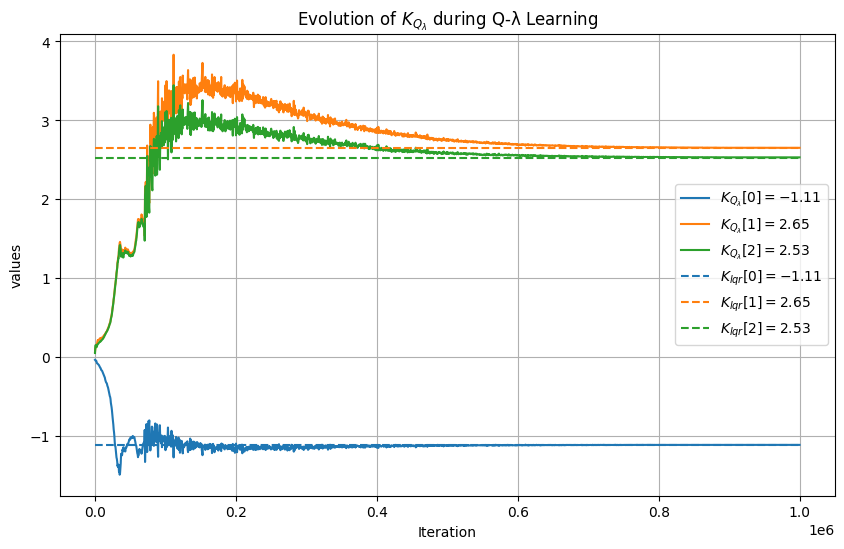

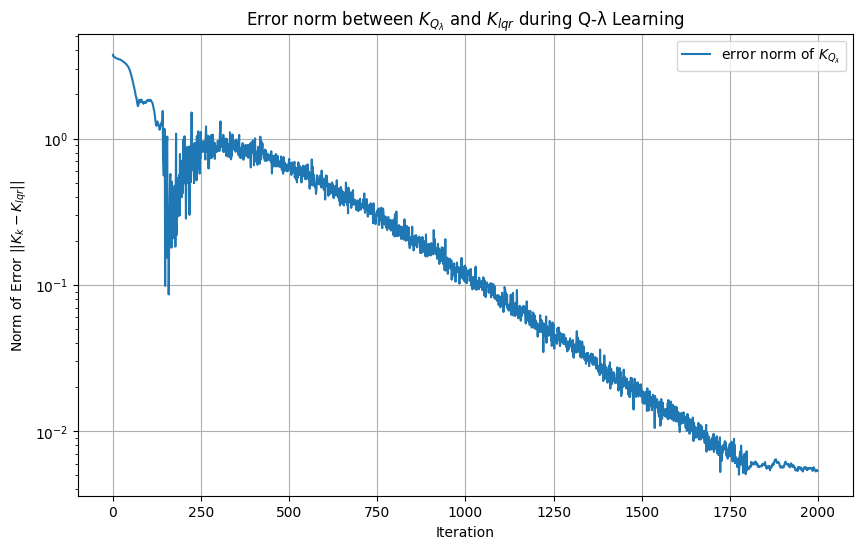

In [ ]:





from Q_lambda import q_lambda_learning_LQR

EXP_NAME = "_online_faster"

#  need to be small enough
f_x0 = lambda: np.multiply(rng.normal(0, 1, size=(3)), np.array([1, 1, 1])) * 0.02

# N = 2000_000
# T = 2
# N, T = 2000_000, 2
# N, T = 400_000, 2
N, T = 500_000, 2
# K_learned, H, data = q_lambda_learning_LQR(model, dataset, lambda_=0, alpha=2e-1, epochs=1)

#### RUN FOR DIFFERENT LAMBDAS


if RUN_QLAMBDA:
    K_Q_lambda, H, data = q_lambda_learning_LQR(model, N, T, f_x0, lambda_=0.8, alpha=4e-1, alpha_mul=[(0.07, 10), (0.9, 0.1)])
    print("Learned K:", K_Q_lambda)
    # graph_data(data, EXP_NAME=EXP_NAME)
    graph_K_evolution({"K_{Q_\\lambda}":np.vstack(data["K"]).squeeze()}, K_lqr, indexes=np.array(data["i"]), K_lqr_name="K_{lqr}", title_suffix="during Q-λ Learning")


    K_arrays_lambda = {}
    for lambda_val in [0.0, 0.2, 0.4, 0.6, 0.8, 0.9]:
        print(f"Training with lambda={lambda_val}")
        K_Q_lambda, H, data = q_lambda_learning_LQR(model, N, T, f_x0, lambda_=lambda_val, alpha=2e-1, alpha_mul=[(0.1, 10), (0.95, 0.1)])
        K_arrays_lambda[f"K_{{Q_\\lambda={lambda_val}}}"] = np.vstack(data["K"]).squeeze()

    graph_K_evolution(K_arrays_lambda, K_lqr, indexes=np.array(data["i"]), K_lqr_name="K_{lqr}", title_suffix="during Q-λ Learning for different λ")




Iter     0, TD Error: 0.0130, Current K: [ 1.85521698e-05  1.33114978e-06 -1.69074010e-06] x: [-0.06 -0.    0.  ] u: [0.] zeta norm: 0.00  cost: 0.0130
Iter 250000, TD Error: 324.6846, Current K: [-3.50304463e-02  9.87407659e-06  5.52374257e-03] x: [-0.12  0.    0.  ] u: [0.01] zeta norm: 0.02  cost: 1.2035
Step size alpha changed to 2.0 at iteration 10000
Iter 500000, TD Error: -30.8461, Current K: [-3.50340405e-02  9.87701974e-06  5.52370686e-03] x: [-0.09  0.   -0.01] u: [0.] zeta norm: 0.01  cost: -0.2224
Iter 750000, TD Error: 1194.7974, Current K: [-3.50501658e-02  9.89547882e-06  5.52339517e-03] x: [ 0.05 -0.   -0.  ] u: [8.18e-05] zeta norm: 0.00  cost: 0.3300
Iter 1000000, TD Error: -392.6710, Current K: [-3.50520745e-02  9.85795363e-06  5.52316103e-03] x: [-0.14  0.   -0.  ] u: [0.01] zeta norm: 0.02  cost: -0.2741
Iter 1250000, TD Error: 1055.8238, Current K: [-3.50502204e-02  9.83421073e-06  5.52316410e-03] x: [ 0.04  0.   -0.  ] u: [0.] zeta norm: 0.00  cost: -0.0570
Iter 

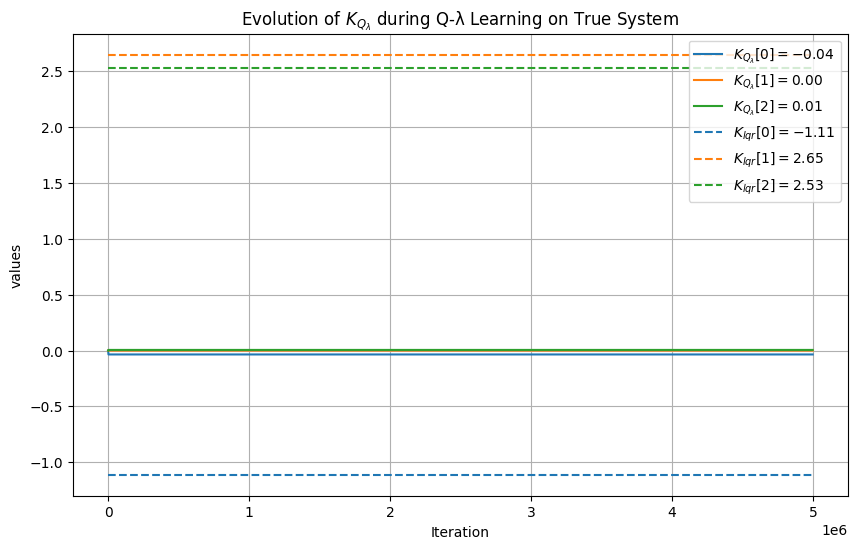

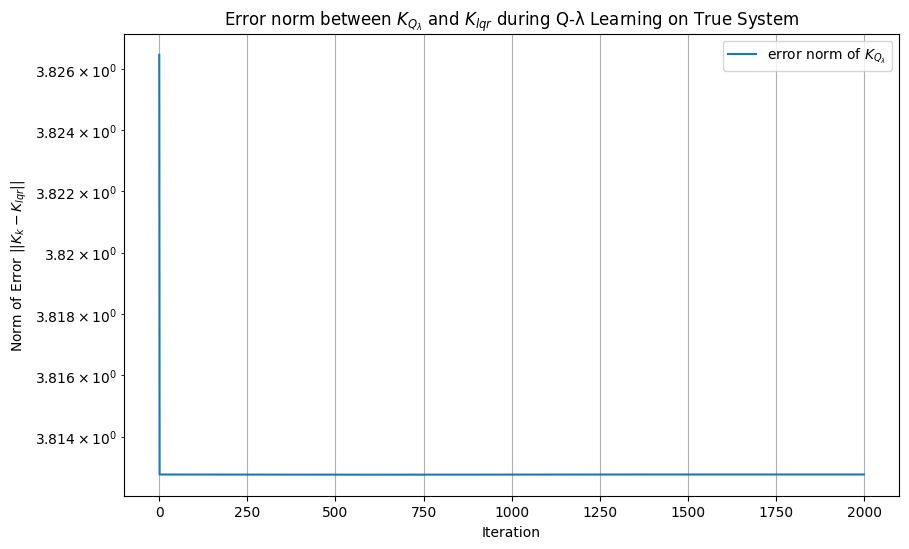

In [35]:
EXP_NAME = "_true_system_samaller_init"

rng = np.random.default_rng(3)  # For reproducibility
#  need to be small enough
f_x0 = lambda: np.multiply(rng.normal(0, 1, size=(3)), np.array([1, SIGMA_A, BETA_U])) * 0.1
# 1: -0.39444651  0.00064731  0.05232715
# 2: [-0.6.62517439  3.81933559e-05  7.27221721e-02]
# 3 : [-0.46880645 -0.0051216   0.01963842]

# N, T = 200_000, 5
# N, T = 1000_000, 2
# N, T = 10000_000, 2
N, T = 5000_000, 10
N, T = 500_000, 10
N, T = 100_000, 50
# K_learned, H, data = q_lambda_learning_LQR(model, dataset, lambda_=0, alpha=2e-1, epochs=1)
if RUN_QLAMBDA:
    K_Q_lambda_TS, H, data = q_lambda_learning_LQR(model, N, T, f_x0, lambda_=0, alpha=2e-1, true_system=True, alpha_mul=[(0.1, 10),  (0.7, 0.1)], u_noise_std=0.001)

    print("Learned K:", K_Q_lambda_TS)
    K_array_Q_lambda = np.vstack(data["K"]).squeeze()
    index_array = np.array(data["i"])
    graph_K_evolution({"K_{Q_\\lambda}":K_array_Q_lambda}, K_lqr, indexes=index_array, title_suffix="during Q-λ Learning on True System")

# graph_data(data, EXP_NAME=EXP_NAME)


Average reward of Q-λ Policy_true_system_samaller_init over 100 trajectories: 1.884353981193254e-05 and std: 0.0001420216921635429


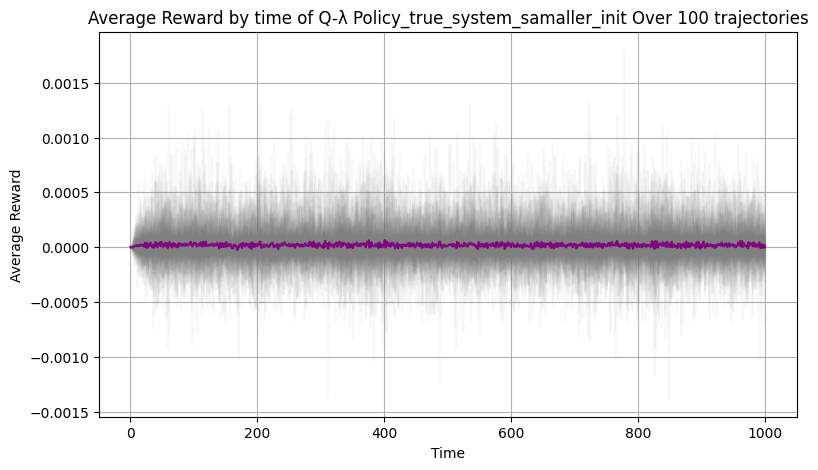

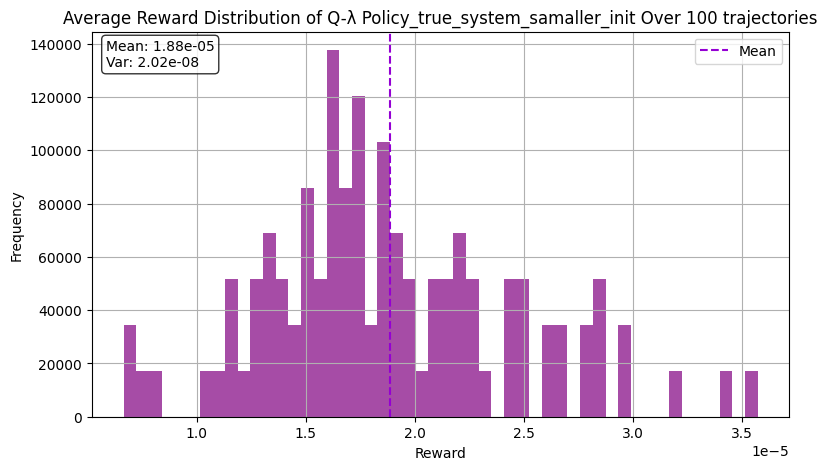

In [19]:
K_Q_lambda_TS = np.array([-0.47, 0, 0.06])  # manually set to a good value found
K_Q_lambda_TS = np.array([-0.0865145, 0.00021523,  0.01188014])  # manually set to a good value found
# K_Q_lambda_TS = np.array([-0.48, 0.5, 0.08])  # manually set to a good value found
EXP_NAME = "_true_system_samaller_init"

Q_lambda_policy_TS = lambda x: K_Q_lambda_TS @ x
policy_list.append((Q_lambda_policy_TS, "Q-λ Policy on True System"))
run_trajectories(Q_lambda_policy_TS, N=100, T=1000, name="Q-λ Policy" + EXP_NAME, show_all=False)

In [20]:
# run_trajectories(Q_lambda_policy_TS, N=100, T=1000, name="Q-λ Policy" + EXP_NAME, show_all=False)



# xi_a = np.zeros((1000, 100))
# xi_p = np.zeros((1000, 100))
# x0 = (0, 0, 0)
# run_trajectories(Q_lambda_policy_TS, N=100, T=1000, name="Q-λ Policy" + EXP_NAME, show_all=False, xi_a=xi_a, xi_p=xi_p, x0=x0)



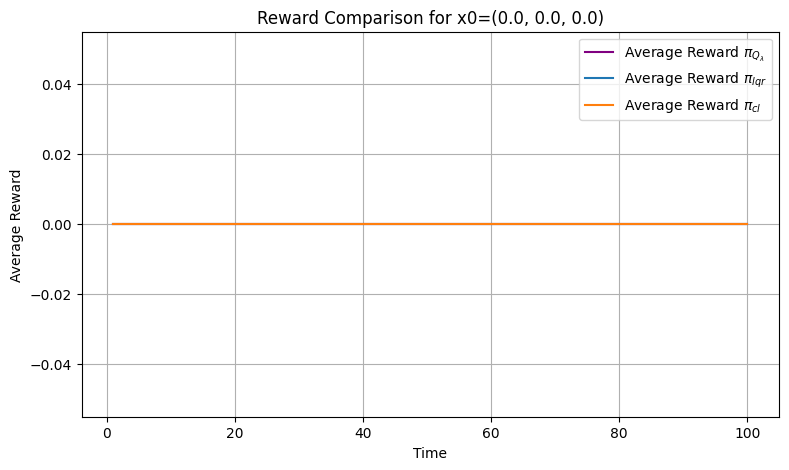

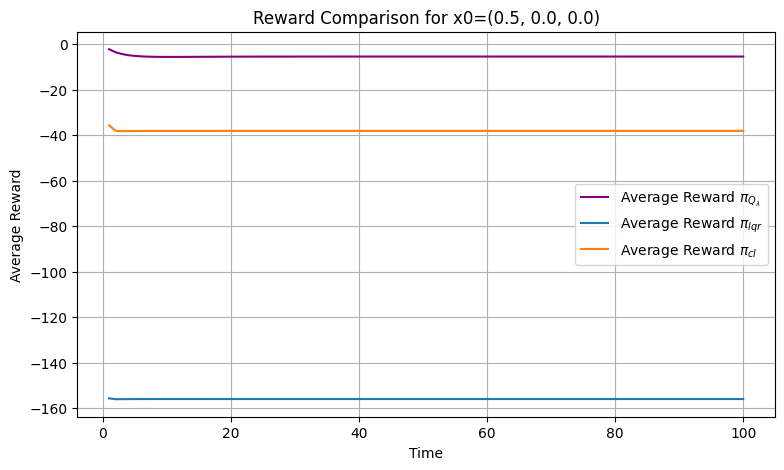

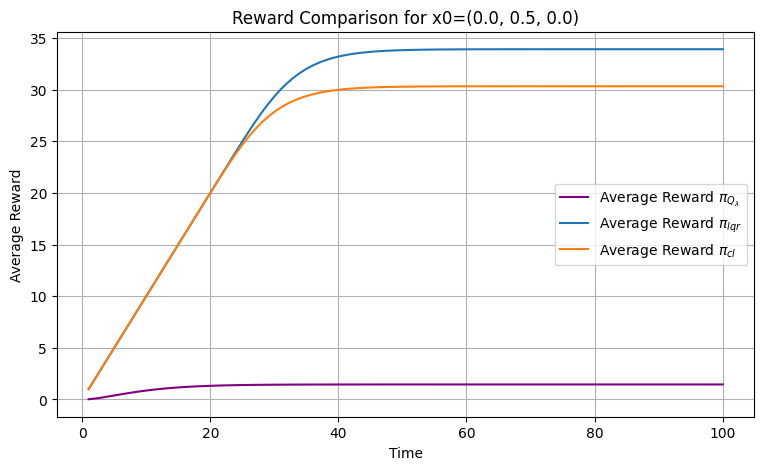

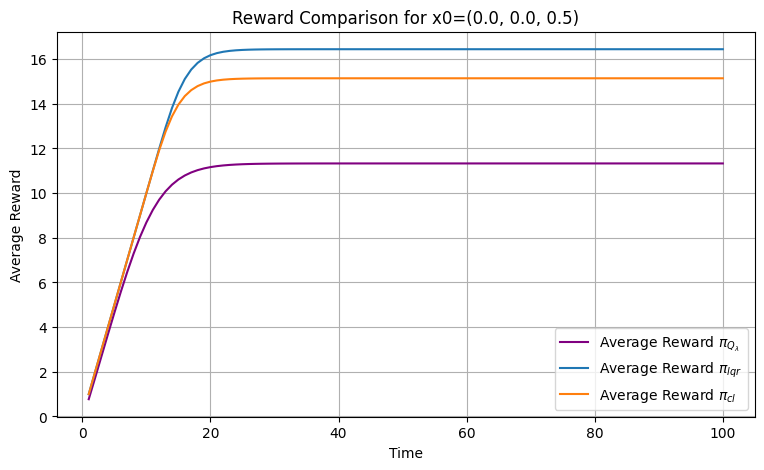

In [21]:

# plot reward for this 3 initial condition
x0_list = [ (0.0, 0.0, 0.0),
            (0.5, 0.0, 0.0),
            (0.0, 0.5, 0.0),
            (0.0, 0.0, 0.5),
            ]
for i, x0 in enumerate(x0_list):
    xi_a = np.zeros((100, 1))
    xi_p = np.zeros((100, 1))
    # run_trajectories(Q_lambda_policy_TS, N=1, T=100, name=f"Q-λ Policy" + EXP_NAME + f"_x0_{i}", show_all=True, xi_a=xi_a, xi_p=xi_p, x0=x0)
    plot_average_reward(*generate_trajectories(Q_lambda_policy_TS, x0=x0, T=100, N=1, xi_a=xi_a, xi_p=xi_p), filename=f"q_lambda_true_system_x0_{i}", policy_label="$\\pi_{Q_\\lambda}$", mode="cum")
    plot_average_reward(*generate_trajectories(lqr_policy, x0=x0, T=100, N=1, xi_a=xi_a, xi_p=xi_p), filename=f"q_lambda_true_system_x0_{i}", append=True, policy_label="$\\pi_{lqr}$", mode="cum")
    plot_average_reward(*generate_trajectories(policy, x0=x0, T=100, N=1, xi_a=xi_a, xi_p=xi_p), filename=f"q_lambda_true_system_x0_{i}", append=True, policy_label="$\\pi_{cl}$", mode="cum")
    plt.title(f"Reward Comparison for x0={x0}")
    plt.savefig(f"figures/q_lambda_true_system_x0_{i}_comparison.svg", format='svg')

In [22]:

# K_array = np.vstack(hist_K).squeeze()
# print("K_array:", K_array)
# graph_data(data, EXP_NAME=EXP_NAME)

Evaluation of all policies over 10000 trajectories ...


Generating trajectories: 100%|██████████| 50/50 [00:00<00:00, 9504.43it/s]


Initial Policy                  Average reward = -0.01045350 , Std = 0.03049793


Generating trajectories: 100%|██████████| 50/50 [00:00<00:00, 1729.51it/s]

LQR Optimal Policy              Average reward = -0.02361284 , Std = 0.06145396



Generating trajectories: 100%|██████████| 50/50 [00:00<00:00, 3934.25it/s]


Q-λ Policy on True System       Average reward = -0.00951292 , Std = 0.04841620


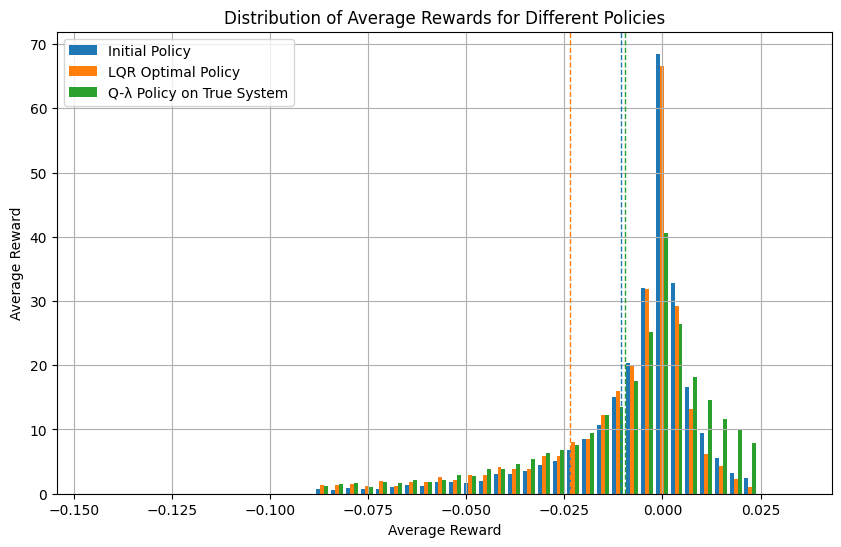

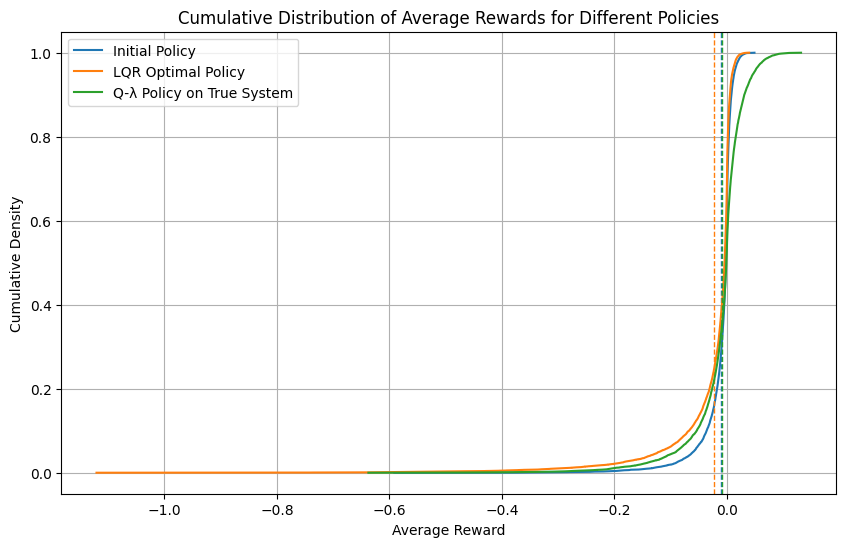

In [23]:
# run for all 3 policies and store the rewards
import matplotlib.pyplot as plt
import numpy as np

# filter out duplicate policies by name
policy_list = list({name: (func, name) for func, name in policy_list}.values())


def plot_reward_distribution(policy_list, name="", n_traj=1000, T=1000, deterministic=False, x0=(0, 0, 0)):
    print(f"Evaluation of all policies over {n_traj} trajectories ...")

    all_rewards = np.zeros((len(policy_list), n_traj))
    for i in range(len(policy_list)):
        xi_a = np.zeros((T, n_traj)) if deterministic else None
        xi_p = np.zeros((T, n_traj)) if deterministic else None
        x, u, xi_p = generate_trajectories(policy_list[i][0], x0=x0, T=T, N=n_traj if "mpc" not in policy_list[i][1].lower() else 1, show_progress=True, xi_a=xi_a, xi_p=xi_p)
        all_rewards[i] = np.nanmean(reward(x, u, xi_p, T), axis=0).T
        print(f"{policy_list[i][1]:30s}  Average reward = {np.nanmean(all_rewards[i]):.8f} , Std = {np.std(all_rewards[i]):.8f}")


    # plot all the rewards
    plt.figure(figsize=(10, 6))
    labels = [policy_list[i][1] for i in range(len(policy_list))]
    # start the box to have 90% of the data
    # plt.hist(all_rewards.T, bins=30, label=labels, alpha=1, density=True)
    start, end = np.percentile(all_rewards, 5), np.percentile(all_rewards, 95)
    plt.hist(all_rewards.T, bins=30, range=(start, end), label=labels, alpha=1, density=True)
    # add the mean of each distribution
    for i in range(all_rewards.shape[0]):
        plt.axvline(np.nanmean(all_rewards[i]), color=f'C{i}', linestyle='dashed', linewidth=1)
    plt.xlabel('Average Reward')

    plt.title('Distribution of Average Rewards for Different Policies')
    plt.ylabel('Average Reward')
    plt.grid()
    ## clip to have 90% of the data
    plt.xlim(np.percentile(all_rewards, 2), np.percentile(all_rewards, 98))
    plt.legend()
    plt.savefig(f"figures/policy_comparison_histogram_{name}.svg", format='svg')


    # the integral plot
    plt.figure(figsize=(10, 6))
    for i in range(all_rewards.shape[0]):
        sorted_rewards = np.sort(all_rewards[i])
        cumulative = np.arange(1, len(sorted_rewards) + 1) / len(sorted_rewards)
        plt.plot(sorted_rewards, cumulative, label=labels[i])
        plt.axvline(np.nanmean(all_rewards[i]), color=f'C{i}', linestyle='dashed', linewidth=1)

    plt.xlabel('Average Reward')
    plt.title('Cumulative Distribution of Average Rewards for Different Policies')
    plt.ylabel('Cumulative Density')
    plt.grid()
    plt.legend()
    plt.savefig(f"figures/policy_comparison_cumulative_distribution_{name}.svg", format='svg')


f_x0 = lambda: np.multiply(rng.normal(0, 1, size=(3)), np.array([1, SIGMA_A, BETA_U])) * 0.1
# f_x0 = lambda: rng.normal(0, 1, size=(3))
# QL, lspi, cl, and lqr
# plot_reward_distribution([pol for pol in policy_list if pol[1] in ["Q-λ Policy on True System", "Q-λ Policy", "LQR Optimal Policy", "Initial Policy"]], name="Q-7-2", n_traj=10000)
plot_reward_distribution([pol for pol in policy_list if pol[1] in ["Q-λ Policy on True System", "LQR Optimal Policy", "Initial Policy"]], name="Q-7-2", n_traj=10000, T=50, deterministic=True, x0=f_x0)


Evaluation of all policies over 1000 trajectories ...


Generating trajectories: 100%|██████████| 1000/1000 [00:00<00:00, 53751.77it/s]


Initial Policy                  Average reward = 0.01158617 , Std = 0.00296200


Generating trajectories: 100%|██████████| 1000/1000 [00:00<00:00, 46866.87it/s]


Clipped Initial Policy          Average reward = 0.00581465 , Std = 0.00233064


Generating trajectories: 100%|██████████| 1000/1000 [00:00<00:00, 55890.52it/s]

Best linear Policy (CMA-ES)     Average reward = 0.00977522 , Std = 0.00479038


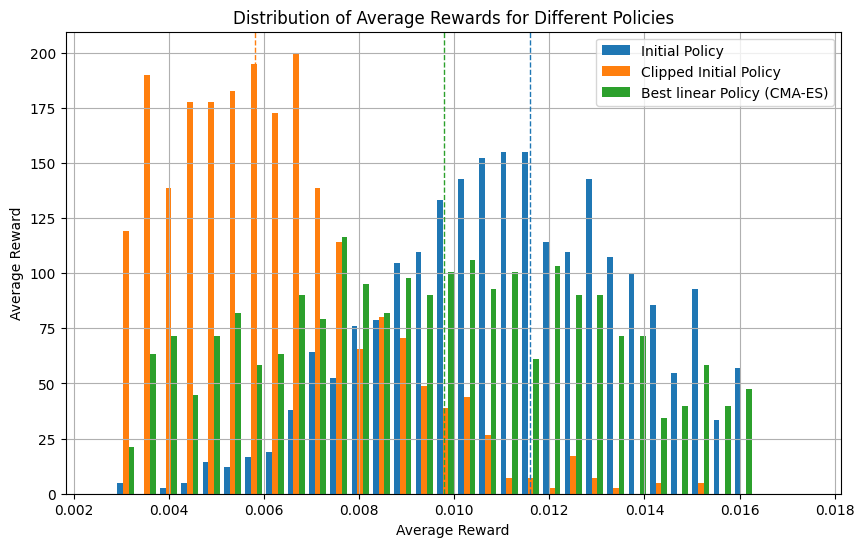

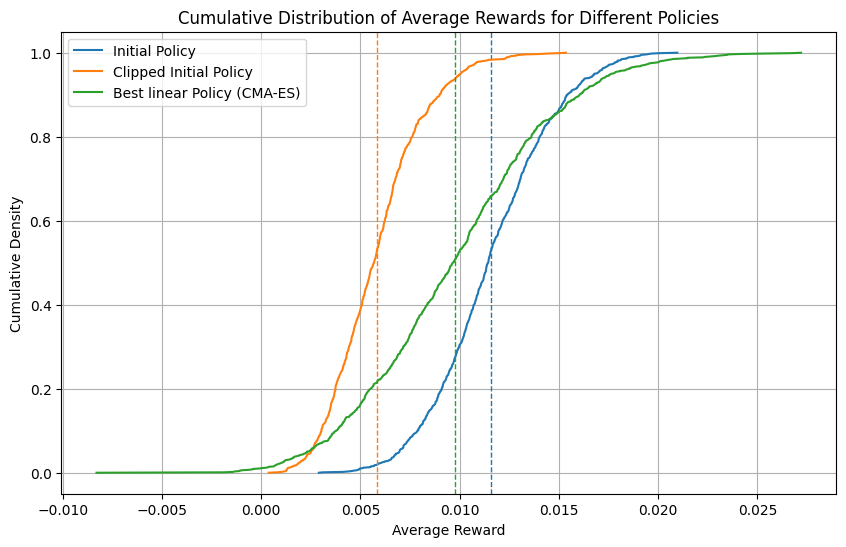

In [24]:

plot_reward_distribution(policy_list[:3], name="first_three", n_traj=1000)

Evaluation of all policies over 1000 trajectories ...


Generating trajectories: 100%|██████████| 1000/1000 [00:00<00:00, 77136.63it/s]


Initial Policy                  Average reward = 0.01152396 , Std = 0.00291140


Generating trajectories: 100%|██████████| 1000/1000 [00:00<00:00, 54656.75it/s]


Clipped Initial Policy          Average reward = 0.00581646 , Std = 0.00235387


...

LQR Clip Policy                 Average reward = 0.00966946 , Std = 0.00484551


Generating trajectories: 100%|██████████| 1000/1000 [00:12<00:00, 77.79it/s]


MPC Optimal Policy              Average reward = 0.01546208 , Std = 0.00000000


Generating trajectories: 100%|██████████| 1000/1000 [00:00<00:00, 86910.57it/s]


Q-λ Policy on True System       Average reward = 0.00001937 , Std = 0.00000643


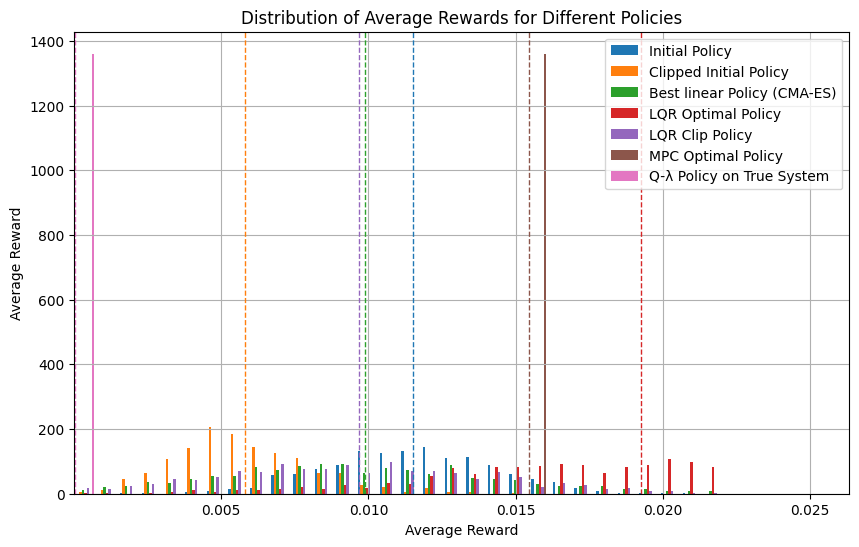

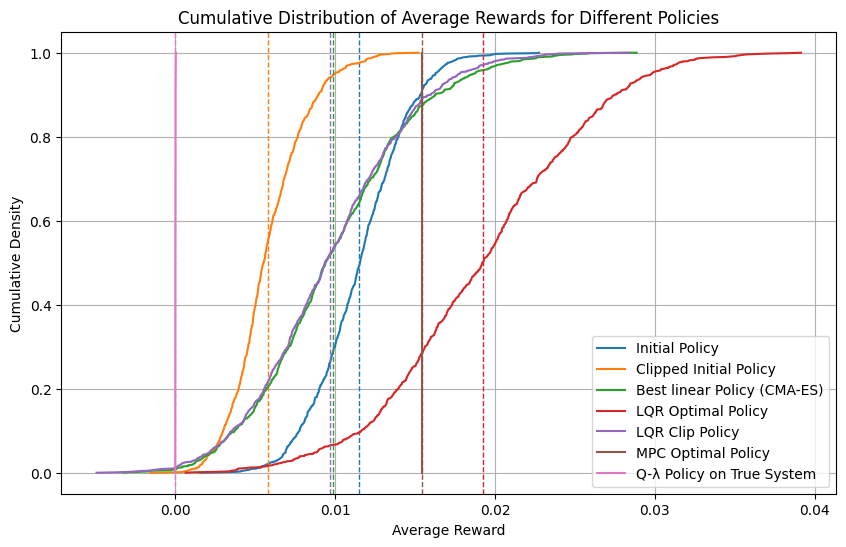

In [25]:
plot_reward_distribution(policy_list, name="all", n_traj=1000)


In [26]:
plt.show()
